Заходим в venv

In [ ]:
!source .venv/bin/activate

In [ ]:
!pip install --upgrade "transformers>=4.46.0" datasets evaluate pycocotools \
    torch torchvision ipywidgets widgetsnbextension timm "accelerate>=0.26.0" \
    albumentations "torchmetrics>=1.3.0" -q


In [ ]:
import torch
import matplotlib.pyplot as plt
import albumentations as A
import numpy as np

from collections import defaultdict
from dataclasses import dataclass
from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForObjectDetection,
    AutoImageProcessor,
    TrainingArguments,
    Trainer,
    pipeline,
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.nn.functional import softmax
from tqdm import tqdm
from PIL import Image, ImageDraw
import os

import os
from typing import Dict, Any, List, Optional, Callable

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset

from pycocotools.coco import COCO
import albumentations as A

from transformers import AutoImageProcessor, AutoModelForObjectDetection



torch.cuda.is_available()


/home/avshink/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


True

На вход скрипту подается уже почищенный датасет с 10 классами, скрипт чистки находится в dataset_filter.py

In [ ]:
# === ПУТИ К MINI-COCO ===
ROOT = "mini_coco_3"
ANN_TRAIN = os.path.join(ROOT, "annotations", "instances_train2017_subset.json")
ANN_VAL   = os.path.join(ROOT, "annotations", "instances_val2017_subset.json")
IMG_TRAIN = os.path.join(ROOT, "train2017")
IMG_VAL   = os.path.join(ROOT, "val2017")

# === ЧЕКПОИНТ МОДЕЛИ ===
CHECKPOINT = "facebook/detr-resnet-50"


In [ ]:
def build_coco_label_maps(train_ann_path: str):
    """
    Строим:
      - id2label/label2id для модели
      - сопоставление COCO category_id -> [0..N-1]
    """
    coco = COCO(train_ann_path)
    cat_ids = coco.getCatIds()
    cats = coco.loadCats(cat_ids)
    # фиксируем порядок по исходному id
    cats = sorted(cats, key=lambda c: c["id"])

    id2label = {i: c["name"] for i, c in enumerate(cats)}
    label2id = {v: k for k, v in id2label.items()}
    coco_id_to_contiguous = {c["id"]: i for i, c in enumerate(cats)}

    return id2label, label2id, coco_id_to_contiguous


Для того чтобы применять аугментацию в этой и следующей ячейках функции для перевода координат

In [ ]:
def coco_to_voc(bbox):
    x, y, w, h = bbox
    return [x, y, x + w, y + h]

def voc_to_coco(bbox):
    xmin, ymin, xmax, ymax = bbox
    return [xmin, ymin, xmax - xmin, ymax - ymin]


def get_train_transform():
    return A.Compose(
        [
            A.LongestMaxSize(500),
            A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.5),
            A.HueSaturationValue(p=0.5),
            A.Rotate(limit=10, p=0.5),
            A.RandomScale(scale_limit=0.2, p=0.5),
            A.GaussianBlur(p=0.5),
            A.GaussNoise(p=0.5),
        ],
        bbox_params=A.BboxParams(
            format="pascal_voc",
            label_fields=["category"],
            min_area=1,
            min_visibility=0.1,
            clip=True,
        ),
    )


def get_val_transform():
    return A.Compose(
        [
            A.LongestMaxSize(500),
            A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
        ],
        bbox_params=A.BboxParams(
            format="pascal_voc",
            label_fields=["category"],
            clip=True,
        ),
    )


In [ ]:
class MiniCocoDataset(Dataset):
    def __init__(
        self,
        img_root: str,
        ann_path: str,
        image_processor,
        coco_id_to_contiguous: Dict[int, int],
        transform: Optional[Callable] = None,
    ):
        self.img_root = img_root
        self.coco = COCO(ann_path)
        self.image_processor = image_processor
        self.coco_id_to_contiguous = coco_id_to_contiguous
        self.transform = transform

        self.image_ids = list(self.coco.imgs.keys())

    def __len__(self) -> int:
        return len(self.image_ids)

    def _load_image(self, image_id: int) -> Image.Image:
        img_info = self.coco.loadImgs(image_id)[0]
        path = os.path.join(self.img_root, img_info["file_name"])
        image = Image.open(path).convert("RGB")
        return image

    def _load_annotations(self, image_id: int) -> Dict[str, Any]:
        ann_ids = self.coco.getAnnIds(imgIds=image_id, iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        bboxes, categories, areas, iscrowd = [], [], [], []

        for ann in anns:
            bbox = ann["bbox"]               # coco [x, y, w, h]
            cat_id = ann["category_id"]
            if cat_id not in self.coco_id_to_contiguous:
                continue
            mapped = self.coco_id_to_contiguous[cat_id]
            bboxes.append(bbox)
            categories.append(mapped)
            areas.append(ann.get("area", bbox[2] * bbox[3]))
            iscrowd.append(ann.get("iscrowd", 0))

        return {
            "bboxes": bboxes,
            "categories": categories,
            "areas": areas,
            "iscrowd": iscrowd,
        }

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        image_id = self.image_ids[idx]
        image = self._load_image(image_id)
        width, height = image.size

        ann = self._load_annotations(image_id)
        bboxes_coco = ann["bboxes"]
        categories = ann["categories"]
        areas = ann["areas"]
        iscrowd = ann["iscrowd"]

        image_np = np.array(image)

        # COCO -> VOC для Albumentations
        bboxes_voc = [coco_to_voc(b) for b in bboxes_coco]

        if self.transform is not None and len(bboxes_voc) > 0:
            out = self.transform(
                image=image_np,
                bboxes=bboxes_voc,
                category=categories,
            )
            image_np = out["image"]
            bboxes_voc = out["bboxes"]
            categories = out["category"]

        # VOC -> COCO обратно
        bboxes_coco = [voc_to_coco(b) for b in bboxes_voc]

        # готовим список аннотаций для image_processor
        annotations_list: List[Dict[str, Any]] = []
        for bbox, cat, area, crowd in zip(bboxes_coco, categories, areas, iscrowd):
            annotations_list.append(
                {
                    "image_id": int(image_id),
                    "category_id": int(cat),
                    "bbox": list(bbox),
                    "area": float(area),
                    "iscrowd": int(crowd),
                }
            )

        annotations_for_processor = {
            "image_id": int(image_id),
            "annotations": annotations_list,
        }

        encoded = self.image_processor(
            images=image_np,
            annotations=annotations_for_processor,
            return_tensors="pt",
        )

        # encoded["labels"] — список длины batch_size, здесь batch=1
        labels = encoded["labels"][0]

        # добавляем orig_size для compute_metrics
        labels["orig_size"] = torch.tensor([height, width], dtype=torch.int64)

        item = {
            "pixel_values": encoded["pixel_values"].squeeze(0),  # (C,H,W)
            "labels": labels,
        }
        if "pixel_mask" in encoded:
            item["pixel_mask"] = encoded["pixel_mask"].squeeze(0)

        return item



In [ ]:
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    # используем image_processor для паддинга батча
    encoding = image_processor.pad(pixel_values, return_tensors="pt")

    labels = [item["labels"] for item in batch]

    out = {
        "pixel_values": encoding["pixel_values"],
        "labels": labels,
    }
    if "pixel_mask" in encoding:
        out["pixel_mask"] = encoding["pixel_mask"]

    return out


In [ ]:
import torch
from torch import Tensor
from torchmetrics.detection.mean_ap import MeanAveragePrecision


def _scale_xywh_relative(boxes: Tensor, h: int, w: int) -> Tensor:
    """
    Перевод нормализованных боксов (xywh в [0,1]) в абсолютные координаты.
    Используются in-place совместимые операции, без лишних аллокаций.
    """
    if boxes.numel() == 0:
        return boxes
    scale = boxes.new_tensor([w, h, w, h])
    return boxes * scale


# один инстанс метрики, который живёт между вызовами compute_metrics
_det_metric = MeanAveragePrecision(
    box_format="xywh",
    iou_type="bbox",
    class_metrics=False,
)

# счётчики для дополнительных агрегатов
_eval_counters = {
    "images": 0,
    "pred_boxes": 0,
    "gt_boxes": 0,
}


def compute_metrics(eval_pred, compute_result: bool = False):
    """
    eval_pred:
      (
        (loss_dict, scores, pred_boxes, last_hidden_state, encoder_last_hidden_state),
        labels
      )

    compute_result:
      False -> только обновляем внутреннее состояние метрики и счётчики;
      True  -> считаем финальные значения, делаем reset() и возвращаем dict.
    """
    global _det_metric, _eval_counters

    (_, scores, pred_boxes, _, _), labels = eval_pred

    batch_targets = []
    batch_preds = []

    for label, logits, boxes_norm in zip(labels, scores, pred_boxes):
        # восстанавливаем размер исходного изображения
        orig = label["orig_size"]
        if hasattr(orig, "tolist"):
            orig = orig.tolist()

        if len(orig) == 1:
            h = w = int(orig[0])
        else:
            h, w = int(orig[0]), int(orig[1])

        _eval_counters["images"] += 1

        # GT
        gt_boxes_abs = _scale_xywh_relative(label["boxes"], h, w)
        batch_targets.append(
            {
                "boxes": gt_boxes_abs,
                "labels": label["class_labels"],
            }
        )
        _eval_counters["gt_boxes"] += gt_boxes_abs.shape[0]

        # Предсказания: последние логиты — фон, их выкидываем
        cls_logits = logits[:, :-1]

        # вместо softmax используем максимум логитов как confidence:
        # порядок детекций сохраняется, а вычислений меньше
        conf_vals, cls_ids = cls_logits.max(dim=-1)

        pred_boxes_abs = _scale_xywh_relative(boxes_norm, h, w)
        batch_preds.append(
            {
                "boxes": pred_boxes_abs,
                "scores": conf_vals,
                "labels": cls_ids,
            }
        )
        _eval_counters["pred_boxes"] += pred_boxes_abs.shape[0]

    # обновляем TorchMetrics по батчу
    _det_metric.update(preds=batch_preds, target=batch_targets)

    # пока не финальный вызов — ничего не считаем
    if not compute_result:
        return {}

    # финальный расчёт и сброс состояния
    raw = _det_metric.compute()
    _det_metric.reset()

    # базовые метрики из TorchMetrics: mAP/mAR на разных IoU и масштабах [web:97]
    # оставляем только глобальные агрегаты, без per-class
    result = {}
    for key in [
        "map",       # COCO-style mAP@[.5:.95]
        "map_50",    # mAP@0.5
        "map_75",    # mAP@0.75
        "mar_1",     # mAR с макс. 1 детекцией на объект
        "mar_10",    # mAR с макс. 10 детекций на объект
        "mar_100",   # mAR с макс. 100 детекций
        "map_small",
        "map_medium",
        "map_large",
    ]:
        if key in raw:
            val = raw[key]
            result[key] = round(val.item() if isinstance(val, torch.Tensor) else float(val), 4)

    num_img = max(_eval_counters["images"], 1)
    num_pred = float(_eval_counters["pred_boxes"])
    num_gt = float(_eval_counters["gt_boxes"])

    result["avg_dets_per_image"] = round(num_pred / num_img, 4)
    result["avg_gt_per_image"] = round(num_gt / num_img, 4)
    result["det_to_gt_ratio"] = round(num_pred / num_gt if num_gt > 0 else 0.0, 4)

    # обнуляем счётчики перед следующей валидацией
    _eval_counters = {"images": 0, "pred_boxes": 0, "gt_boxes": 0}

    return result


In [ ]:
# === МАППИНГИ КЛАССОВ ===
id2label, label2id, coco_id_to_contiguous = build_coco_label_maps(ANN_TRAIN)

image_processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
)

train_transform = get_train_transform()
val_transform = get_val_transform()

train_dataset = MiniCocoDataset(
    img_root=IMG_TRAIN,
    ann_path=ANN_TRAIN,
    image_processor=image_processor,
    coco_id_to_contiguous=coco_id_to_contiguous,
    transform=train_transform,
)

val_dataset = MiniCocoDataset(
    img_root=IMG_VAL,
    ann_path=ANN_VAL,
    image_processor=image_processor,
    coco_id_to_contiguous=coco_id_to_contiguous,
    transform=val_transform,
)

model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)


loading annotations into memory...
Done (t=1.67s)
creating index...
index created!


/tmp/ipykernel_1416433/503876305.py:15: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
/tmp/ipykernel_1416433/503876305.py:38: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),


loading annotations into memory...
Done (t=1.59s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


/home/avshink/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/avshink/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/avshink/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is

КАК ЖЕ ХОРОШО, ЧТО Я СОХРАНЯЛ ЧЕКПОИНТЫ, обучение стопнулось на 9й эпохе, восстановил по resume

In [ ]:
from transformers import TrainingArguments, Trainer

output_dir = "detr-resnet-50-new"

def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]

    batch_out = {
        "pixel_values": encoding["pixel_values"],
        "labels": labels,
    }
    if "pixel_mask" in encoding:
        batch_out["pixel_mask"] = encoding["pixel_mask"]

    return batch_out


training_args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    fp16=True,
    save_steps=10_000,
    logging_steps=100,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    eval_steps=1_000,
    eval_strategy="steps",
    report_to="tensorboard",
    push_to_hub=False,
    batch_eval_metrics=True,
    no_cuda=False,
    use_cpu=False,
    dataloader_pin_memory=True,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
)

print(f"Device: {trainer.model.device}")

trainer.train(resume_from_checkpoint=True)


/tmp/ipykernel_1416433/1948720037.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Device: cuda:0


Step,Training Loss,Validation Loss,Map,Map 50,Map 75,Mar 1,Mar 10,Mar 100,Map Small,Map Medium,Map Large,Avg Dets Per Image,Avg Gt Per Image,Det To Gt Ratio
81000,1.359800,0.986393,0.380000,0.583900,0.400700,0.274600,0.509400,0.576000,0.103000,0.322500,0.582100,100.000000,3.201600,31.234300
82000,1.403100,0.985570,0.380800,0.584900,0.401000,0.276200,0.509800,0.576900,0.102300,0.327100,0.582200,100.000000,3.201600,31.234300
83000,1.321900,0.986758,0.383300,0.586400,0.403800,0.277800,0.512300,0.577200,0.113300,0.329100,0.584700,100.000000,3.201600,31.234300
84000,1.352800,0.984749,0.384400,0.587700,0.405400,0.277400,0.513300,0.578100,0.110200,0.328500,0.586600,100.000000,3.201600,31.234300
85000,1.396300,0.984070,0.382000,0.585900,0.404400,0.276000,0.510200,0.575100,0.099500,0.327100,0.582500,100.000000,3.201600,31.234300
86000,1.383600,0.984078,0.383300,0.588000,0.405000,0.277200,0.510300,0.576200,0.105300,0.326500,0.585400,100.000000,3.201600,31.234300
87000,1.348400,0.985022,0.384500,0.588900,0.406500,0.277400,0.511500,0.577100,0.105900,0.326400,0.587100,100.000000,3.201600,31.234300
88000,1.289900,0.984740,0.384500,0.588900,0.406300,0.277100,0.512000,0.577400,0.102600,0.327000,0.587300,100.000000,3.201600,31.234300


TrainOutput(global_step=88020, training_loss=0.1255198023422716, metrics={'train_runtime': 2819.3135, 'train_samples_per_second': 124.881, 'train_steps_per_second': 31.22, 'total_flos': 1.682345988873216e+20, 'train_loss': 0.1255198023422716, 'epoch': 10.0})

Проверим лог

In [ ]:
for entry in trainer.state.log_history:
    print(entry)


{'epoch': 0.011361054305839582, 'grad_norm': 173.56118774414062, 'learning_rate': 9.98875255623722e-06, 'loss': 3.5295, 'step': 100}
{'epoch': 0.022722108611679163, 'grad_norm': 44.36103057861328, 'learning_rate': 9.977391501931381e-06, 'loss': 3.0927, 'step': 200}
{'epoch': 0.03408316291751875, 'grad_norm': 129.3361053466797, 'learning_rate': 9.966030447625541e-06, 'loss': 2.5193, 'step': 300}
{'epoch': 0.04544421722335833, 'grad_norm': 237.37757873535156, 'learning_rate': 9.954669393319702e-06, 'loss': 2.7248, 'step': 400}
{'epoch': 0.05680527152919791, 'grad_norm': 39.44990539550781, 'learning_rate': 9.943308339013862e-06, 'loss': 2.567, 'step': 500}
{'epoch': 0.0681663258350375, 'grad_norm': 43.05234146118164, 'learning_rate': 9.931947284708022e-06, 'loss': 2.3086, 'step': 600}
{'epoch': 0.07952738014087707, 'grad_norm': 112.00341796875, 'learning_rate': 9.920586230402182e-06, 'loss': 2.4104, 'step': 700}
{'epoch': 0.09088843444671665, 'grad_norm': 55.32793426513672, 'learning_rate

In [ ]:
save_dir = "./save-model"

trainer.save_model(save_dir)
trainer.save_state()
image_processor.save_pretrained(save_dir)

['./save-model/preprocessor_config.json']

импортируем сохраненную модель

In [ ]:
from transformers import AutoImageProcessor, AutoModelForObjectDetection, pipeline
import torch

save_dir = "./save-model"

image_processor = AutoImageProcessor.from_pretrained(save_dir)
model = AutoModelForObjectDetection.from_pretrained(save_dir)

detector = pipeline(
    task="object-detection",
    model=model,
    image_processor=image_processor,
    device=0 if torch.cuda.is_available() else -1,
)


Device set to use cuda:0


Посмотрим на детекцию на валидационных данных

Image ID: 458, num detections: 0


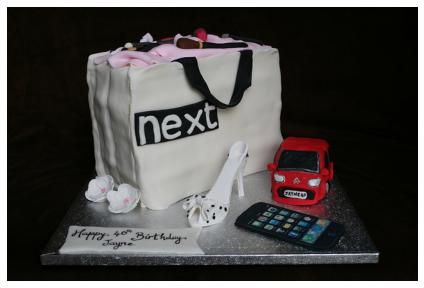

Image ID: 286, num detections: 1


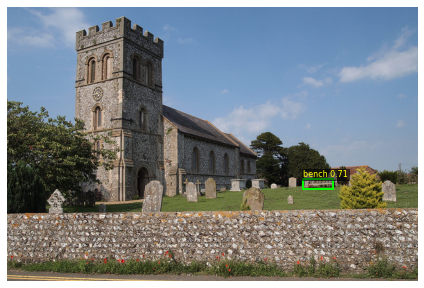

Image ID: 210, num detections: 13


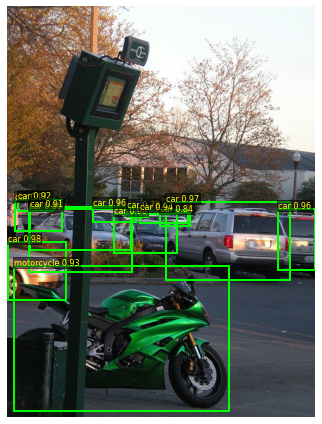

Image ID: 1386, num detections: 9


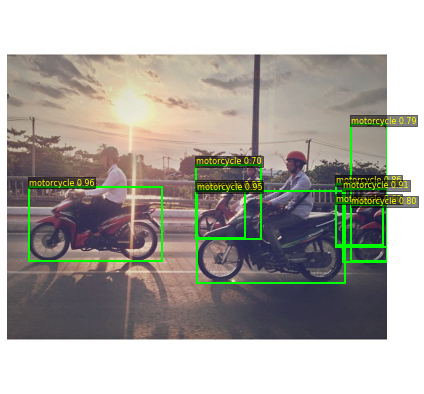

Image ID: 1117, num detections: 1


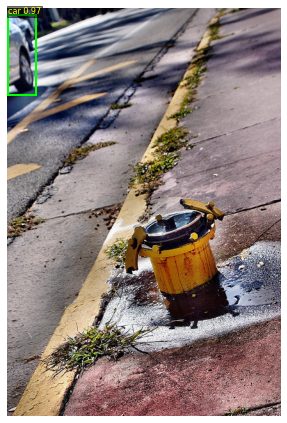

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_detections(image, preds, score_thresh=0.5):
    """
    image: PIL.Image или np.ndarray (H,W,3)
    preds: список dict от pipeline: {'score', 'label', 'box': {'xmin','ymin','xmax','ymax'}}
    """
    if not isinstance(image, np.ndarray):
        img = np.array(image)
    else:
        img = image

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    ax.axis("off")

    for det in preds:
        if det["score"] < score_thresh:
            continue
        box = det["box"]
        xmin, ymin, xmax, ymax = box["xmin"], box["ymin"], box["xmax"], box["ymax"]
        w, h = xmax - xmin, ymax - ymin

        rect = patches.Rectangle(
            (xmin, ymin), w, h,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            xmin,
            max(ymin - 2, 0),
            f"{det['label']} {det['score']:.2f}",
            fontsize=8,
            color="yellow",
            bbox=dict(facecolor="black", alpha=0.5, pad=1),
        )

    plt.tight_layout()
    plt.show()

# случайные N примеров из val_dataset
num_examples = 5
indices = random.sample(range(len(val_dataset)), k=num_examples)

for idx in indices:
    # достаем image_id и исходное изображение через внутренний COCO
    image_id = val_dataset.image_ids[idx]
    raw_image = val_dataset._load_image(image_id)  # использует путь IMG_VAL + file_name

    preds = detector(raw_image)
    print(f"Image ID: {image_id}, num detections: {len(preds)}")
    show_detections(raw_image, preds, score_thresh=0.5)


Метрики на валидациионных данных

In [ ]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm
from IPython.display import display, HTML, clear_output

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

metric = MeanAveragePrecision(box_format="xywh", class_metrics=True)

@torch.no_grad()
def evaluate_on_val():
    display(HTML("<b>Запуск оценки на валидации... это может занять время.</b>"))

    for i in tqdm(
        range(len(val_dataset)),
        desc="Evaluating on val",
        ncols=80,
        leave=False,   # прогресс‑бар исчезнет после конца
    ):
        sample = val_dataset[i]
        pixel_values = sample["pixel_values"].unsqueeze(0).to(device)  # (1,C,H,W)
        labels = sample["labels"]

        outputs = model(pixel_values=pixel_values)

        logits = outputs.logits[0]          # (num_queries, num_classes+1)
        boxes_norm = outputs.pred_boxes[0]  # (num_queries, 4), xywh in [0,1]

        scores_no_bg = logits[:, :-1].softmax(-1)
        scores_max, labels_pred = scores_no_bg.max(dim=-1)

        orig = labels["orig_size"]
        if hasattr(orig, "tolist"):
            orig = orig.tolist()
        if len(orig) == 1:
            h = w = int(orig[0])
        else:
            h, w = int(orig[0]), int(orig[1])

        scale = torch.tensor([w, h, w, h], device=device, dtype=boxes_norm.dtype)

        # GT боксы и классы тоже на device
        gt_boxes_abs = labels["boxes"].to(device) * scale
        gt_labels = labels["class_labels"].to(device)

        pred_boxes_abs = boxes_norm * scale

        preds = [
            {
                "boxes": pred_boxes_abs,
                "scores": scores_max,
                "labels": labels_pred,
            }
        ]
        targets = [
            {
                "boxes": gt_boxes_abs,
                "labels": gt_labels,
            }
        ]

        metric.update(preds=preds, target=targets)

    # очищаем "лоадер" и пишем, что всё готово
    clear_output(wait=True)
    print("Оценка на валидации завершена.")

    return metric.compute()

metrics = evaluate_on_val()


Оценка на валидации завершена.


mAP@[.5:.95]: 0.27147459983825684
mAP@0.5:     0.4248686134815216
mAP@0.75:    0.28517526388168335
mAR@100:     0.5721049308776855


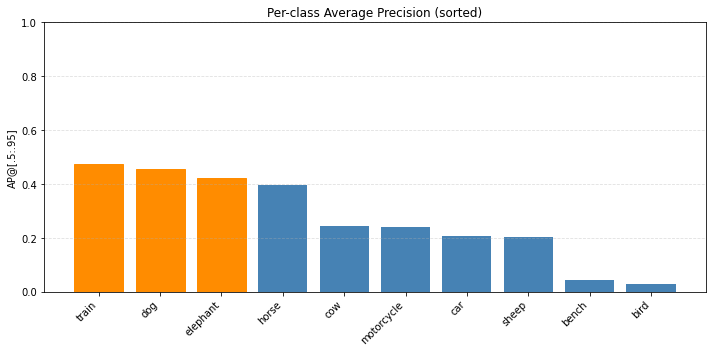

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# глобальные числа
print("mAP@[.5:.95]:", float(metrics["map"]))
print("mAP@0.5:    ", float(metrics["map_50"]))
print("mAP@0.75:   ", float(metrics["map_75"]))
print("mAR@100:    ", float(metrics["mar_100"]))

classes_tensor = metrics["classes"]
map_per_class = metrics["map_per_class"]

class_ids = classes_tensor.cpu().tolist()
class_names = [id2label[cid] for cid in class_ids]
aps = map_per_class.cpu().tolist()

order = np.argsort(aps)[::-1]
sorted_names = [class_names[i] for i in order]
sorted_aps = [aps[i] for i in order]

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(sorted_names)), sorted_aps, color="steelblue")
plt.xticks(range(len(sorted_names)), sorted_names, rotation=45, ha="right")
plt.ylabel("AP@[.5:.95]")
plt.title("Per-class Average Precision (sorted)")
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

top_n = min(3, len(sorted_names))
for i in range(top_n):
    bars[i].set_color("darkorange")

plt.tight_layout()
plt.show()
